# Decision Trees & Random Forests

**Goal:** Master the two most-used non-linear models in tabular ML.

**Why it matters:**
- **Decision Trees** are the most interpretable non-linear model — you can literally draw them.
- **Random Forests** are the workhorse baseline. On tabular data, they often beat neural nets out of the box.
- Both handle **mixed feature types**, **non-linear relationships**, and **feature interactions** automatically.
- They're the foundation for **XGBoost / LightGBM** (next notebook).

**Prerequisite:** [01-linear-logistic.ipynb](./01-linear-logistic.ipynb)

**Dataset:** Titanic

---


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(42)



In [17]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df["HasCabin"] = df["Cabin"].notna().astype(int)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)


df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(lambda x: x.fillna(x.median()))
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch",
         "Fare", "Embarked", "HasCabin", "FamilySize", "IsAlone"]]

X = df.drop(columns=["Survived"])
y = df["Survived"]

numeric_features = ["Age", "SibSp", "Parch", "Fare", "HasCabin", "FamilySize", "IsAlone"]
categorical_features = ["Pclass", "Sex", "Embarked"]

# Preprocessing pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    # StandardScaler NOT needed for trees
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # OneHotEncoder with drop=None (not "first") — trees don't care about collinearity
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop=None)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (712, 10), Test: (179, 10)


## PART 1 — Decision Tree

### The Idea

A Decision Tree recursively splits the data:
1. Find the feature + threshold that best separates the target
2. Split into two branches
3. Repeat on each branch until a stopping condition



In [18]:

tree_default = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42)),
             
])

tree_default.fit(X_train, y_train)

train_acc = tree_default.score(X_train, y_train)
test_acc  = tree_default.score(X_test, y_test)

print(f"Default tree — Train: {train_acc:.4f}, Test: {test_acc:.4f}")
print(f"Tree depth: {tree_default.named_steps['model'].get_depth()}")
print(f"Number of leaves: {tree_default.named_steps['model'].get_n_leaves()}")


Default tree — Train: 0.9860, Test: 0.7374
Tree depth: 18
Number of leaves: 163


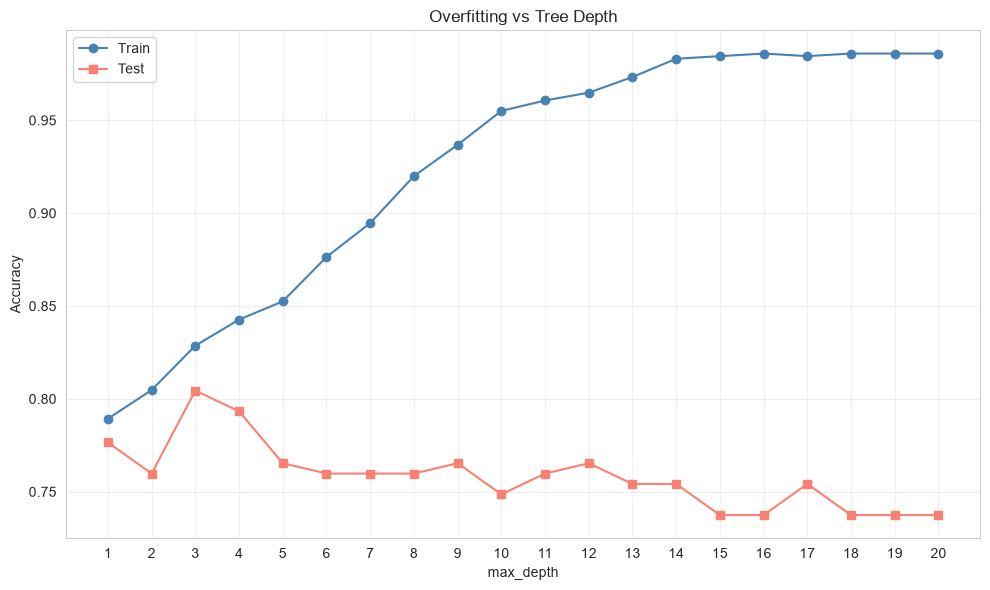

Best depth by test accuracy: 3


In [19]:
depths = range(1, 21)
train_scores, test_scores = [], []

for d in depths:
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(max_depth=d, random_state=42)),
        
    ])
    pipe.fit(X_train, y_train)
    train_scores.append(pipe.score(X_train, y_train))
    test_scores.append(pipe.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, "o-", label="Train", color="steelblue")
plt.plot(depths, test_scores,  "s-", label="Test",  color="salmon")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Overfitting vs Tree Depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.tight_layout()
plt.show()

# Best depth (highest test score)
best_depth = list(depths)[int(np.argmax(test_scores))]
print(f"Best depth by test accuracy: {best_depth}")

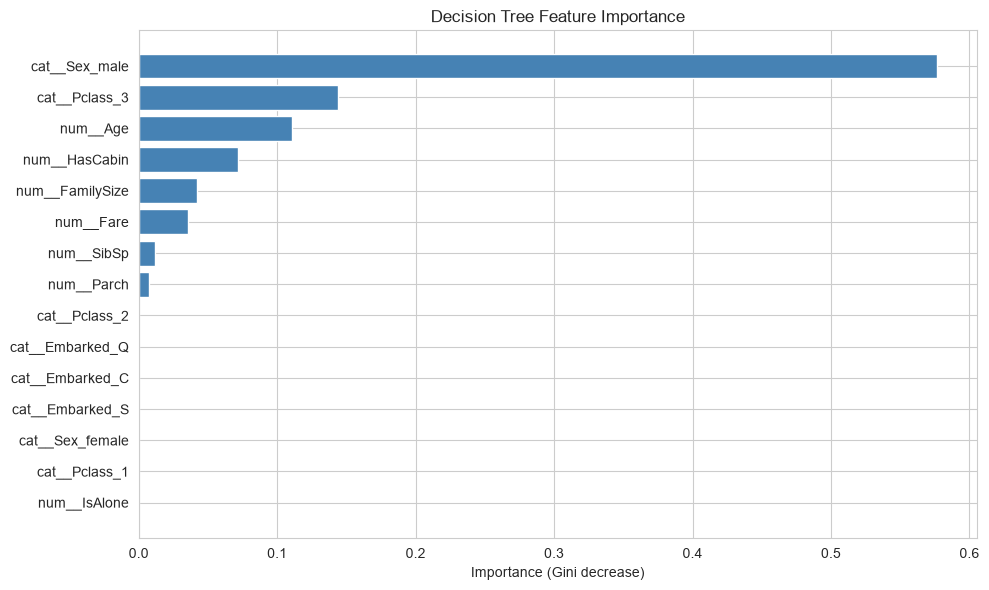

        feature  importance
num__FamilySize      0.0419
  num__HasCabin      0.0717
       num__Age      0.1106
  cat__Pclass_3      0.1438
  cat__Sex_male      0.5766


In [20]:
# Fit a reasonable tree
tree_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42)),
])
tree_pipe.fit(X_train, y_train)


feature_names = tree_pipe.named_steps["preprocessor"].get_feature_names_out()

importances = pd.DataFrame({
    "feature": feature_names,
    "importance": tree_pipe.named_steps["model"].feature_importances_,
    
}).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importances["feature"], importances["importance"], color="steelblue")
plt.xlabel("Importance (Gini decrease)")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

print(importances.tail(5).round(4).to_string(index=False))

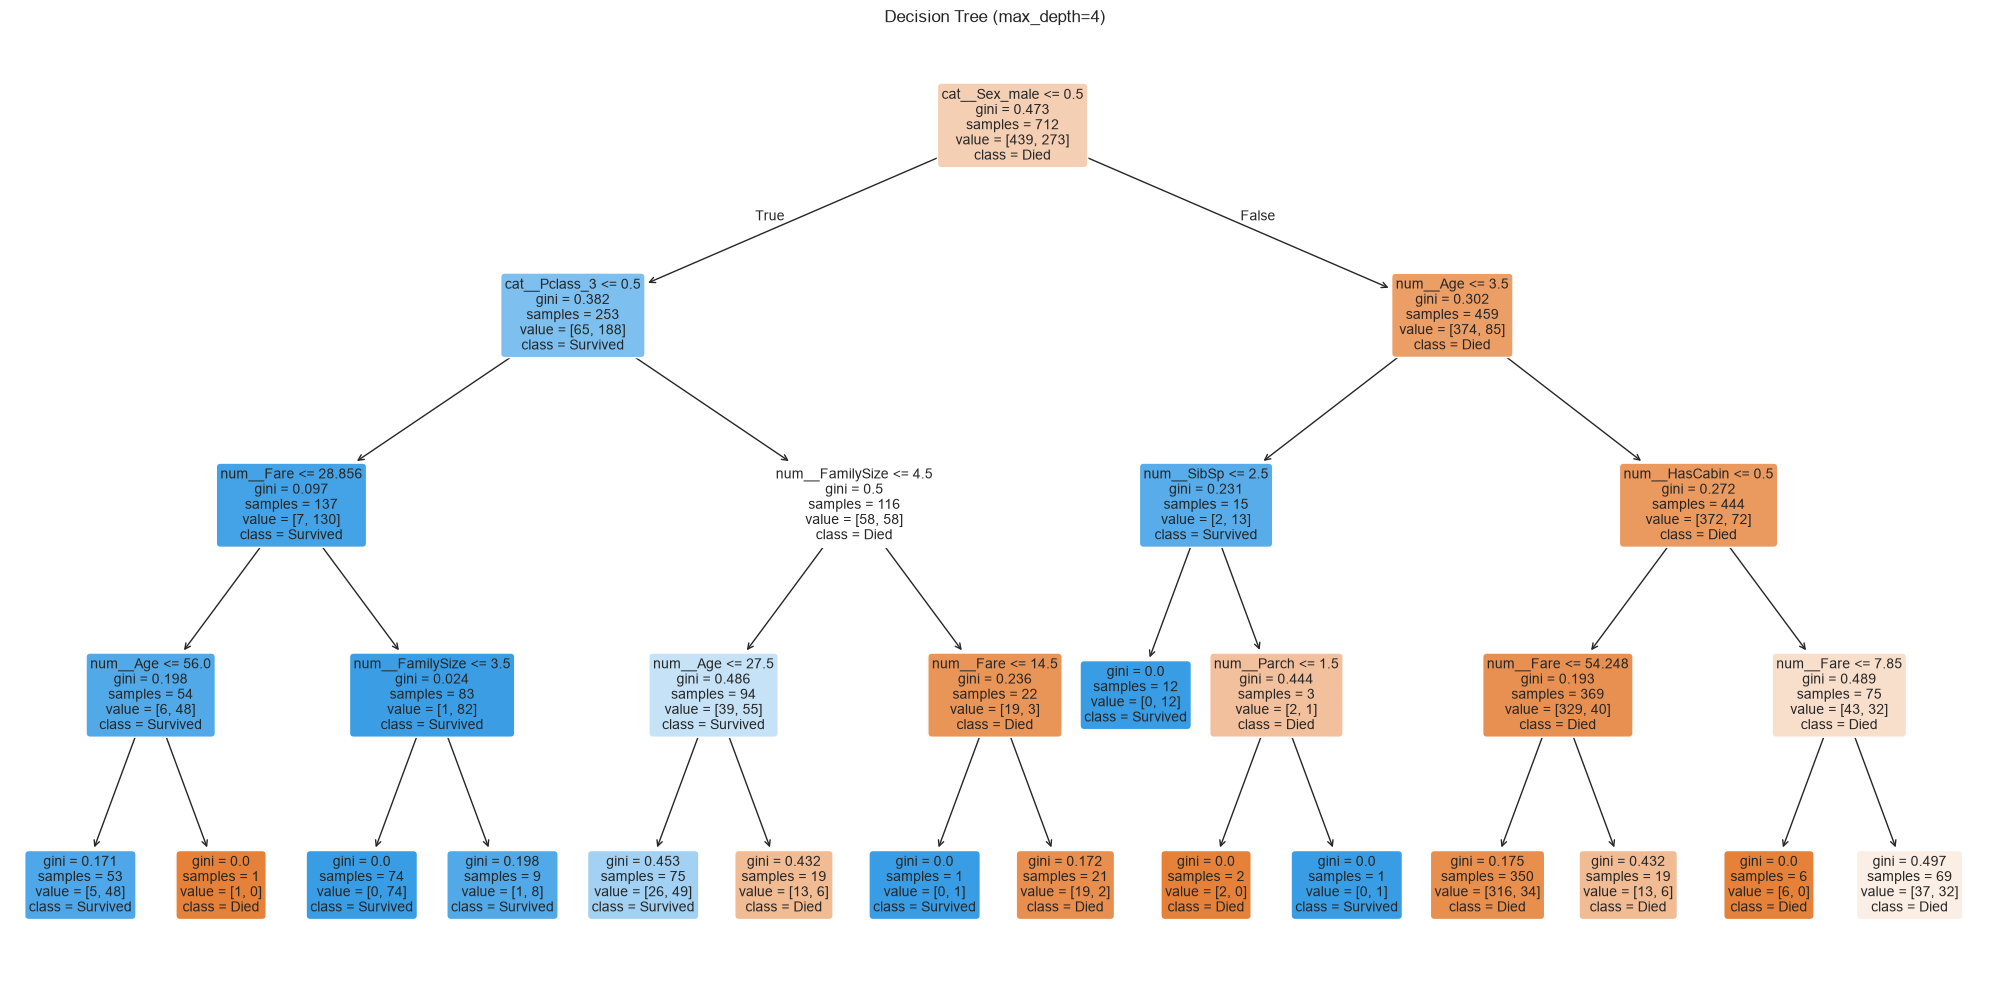

In [21]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree_pipe.named_steps["model"],
    feature_names=tree_pipe.named_steps["preprocessor"].get_feature_names_out(),
    class_names=["Died", "Survived"],
    filled=True,
    
    rounded=True,
    
    fontsize=10,
    impurity=True,
    
    proportion=False,
    
)
plt.title("Decision Tree (max_depth=4)")
plt.tight_layout()
plt.show()

In [22]:
rules = export_text(
    tree_pipe.named_steps["model"],
    feature_names=list(tree_pipe.named_steps["preprocessor"].get_feature_names_out()),
    decimals=2,
    
)
print(rules[:1500])

|--- cat__Sex_male <= 0.50
|   |--- cat__Pclass_3 <= 0.50
|   |   |--- num__Fare <= 28.86
|   |   |   |--- num__Age <= 56.00
|   |   |   |   |--- class: 1
|   |   |   |--- num__Age >  56.00
|   |   |   |   |--- class: 0
|   |   |--- num__Fare >  28.86
|   |   |   |--- num__FamilySize <= 3.50
|   |   |   |   |--- class: 1
|   |   |   |--- num__FamilySize >  3.50
|   |   |   |   |--- class: 1
|   |--- cat__Pclass_3 >  0.50
|   |   |--- num__FamilySize <= 4.50
|   |   |   |--- num__Age <= 27.50
|   |   |   |   |--- class: 1
|   |   |   |--- num__Age >  27.50
|   |   |   |   |--- class: 0
|   |   |--- num__FamilySize >  4.50
|   |   |   |--- num__Fare <= 14.50
|   |   |   |   |--- class: 1
|   |   |   |--- num__Fare >  14.50
|   |   |   |   |--- class: 0
|--- cat__Sex_male >  0.50
|   |--- num__Age <= 3.50
|   |   |--- num__SibSp <= 2.50
|   |   |   |--- class: 1
|   |   |--- num__SibSp >  2.50
|   |   |   |--- num__Parch <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- num__Parch > 

## PART 2 — Random Forest

### The Idea

A single tree overfits. **An ensemble of decorrelated trees** doesn't.

**Random Forest = Bagging + Feature Randomness**

1. **Bagging**: train each tree on a random sample with replacement
2. **Feature randomness**: at each split, consider only a random subset of features
3. **Aggregate**: majority vote (classification) or average (regression)

### Why it Works

- **Bagging** → each tree sees different data → different errors
- **Feature sampling** → trees are less correlated → ensemble variance drops
- Result: high accuracy, robust to overfitting, minimal tuning

### Key Hyperparameters

| Parameter | Default | Meaning |
|-----------|---------|---------|
| `n_estimators` | 100 | Number of trees |
| `max_depth` | None | Usually let trees grow |
| `max_features` | `"sqrt"` | Features per split |
| `min_samples_leaf` | 1 | Min samples in leaf |
| `n_jobs` | None | Parallelization |

In [23]:
rf_baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
    )),
])
rf_baseline.fit(X_train,y_train)
y_pred_rf = rf_baseline.predict(X_test)
y_proba_rf = rf_baseline.predict_proba(X_test)[:,1]

print(f"Train accuracy: {rf_baseline.score(X_train, y_train):.4f}")
print(f"Test  accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"F1            : {f1_score(y_test, y_pred_rf):.4f}")

Train accuracy: 0.9860
Test  accuracy: 0.7989
ROC-AUC       : 0.8226
F1            : 0.7273


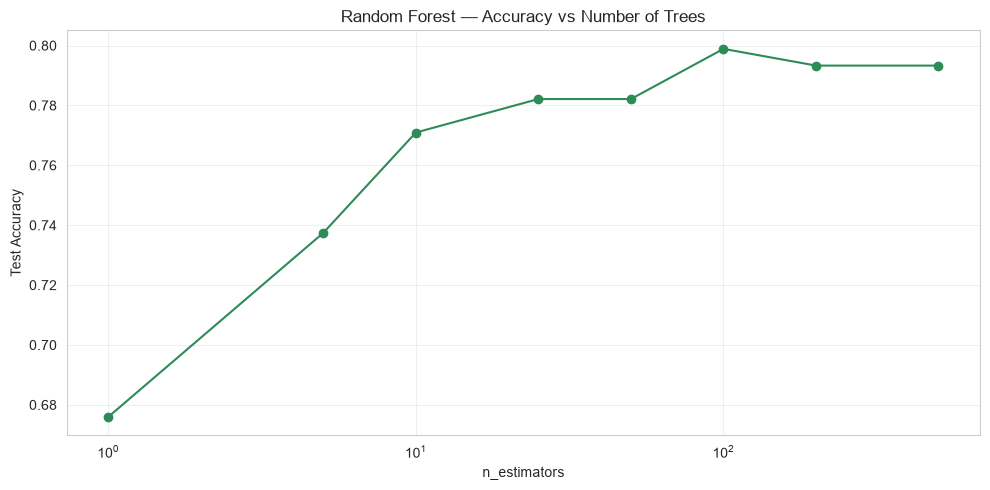

n_estimators=   1 → test acc = 0.6760
n_estimators=   5 → test acc = 0.7374
n_estimators=  10 → test acc = 0.7709
n_estimators=  25 → test acc = 0.7821
n_estimators=  50 → test acc = 0.7821
n_estimators= 100 → test acc = 0.7989
n_estimators= 200 → test acc = 0.7933
n_estimators= 500 → test acc = 0.7933


In [24]:
n_trees_range = [1, 5, 10, 25, 50, 100, 200, 500]
test_scores = []

for n in n_trees_range:
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)),
    ])
    pipe.fit(X_train, y_train)
    test_scores.append(pipe.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(n_trees_range, test_scores, "o-", color="seagreen")
plt.xlabel("n_estimators")
plt.ylabel("Test Accuracy")
plt.title("Random Forest — Accuracy vs Number of Trees")
plt.xscale("log")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for n, s in zip(n_trees_range, test_scores):
    print(f"n_estimators={n:4d} → test acc = {s:.4f}")

## PART 3 — Hyperparameter Tuning with GridSearchCV

### The Idea

You've seen the important hyperparameters. Now we search for the best combination **automatically**.

**GridSearchCV:**
1. Define a grid of parameter values
2. Train a model for every combination
3. Evaluate each with cross-validation
4. Return the best

**Cost:** `n_combinations × cv_folds × training_time`.

In [25]:
param_grid = {"model__n_estimators" :[100 , 200],
              "model__max_depth": [None, 5, 10],
              "model__min_samples_leaf": [1, 5],}

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True,
    
)

grid.fit(X_train, y_train)

print(f"\nBest params: {grid.best_params_}")
print(f"Best CV score: {grid.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Best CV score: 0.8735


In [26]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1       : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_best):.4f}")

Accuracy : 0.7989
Precision: 0.8000
Recall   : 0.6377
F1       : 0.7097
ROC-AUC  : 0.8384


In [28]:
from sklearn.linear_model import LogisticRegression
# Baseline Logistic Regression (from previous notebook) — same pipeline pattern
logreg_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])
logreg_pipe.fit(X_train, y_train)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree (d=4)", "Random Forest (tuned)"],
    "Accuracy": [
        accuracy_score(y_test, logreg_pipe.predict(X_test)),
        accuracy_score(y_test, tree_pipe.predict(X_test)),
        accuracy_score(y_test, y_pred_best),
    ],
    "F1": [
        f1_score(y_test, logreg_pipe.predict(X_test)),
        f1_score(y_test, tree_pipe.predict(X_test)),
        f1_score(y_test, y_pred_best),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, logreg_pipe.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, tree_pipe.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, y_proba_best),
    ],
})

print(comparison.round(4).to_string(index=False))

                Model  Accuracy     F1  ROC-AUC
  Logistic Regression    0.8156 0.7442   0.8422
  Decision Tree (d=4)    0.7933 0.6942   0.8109
Random Forest (tuned)    0.7989 0.7097   0.8384


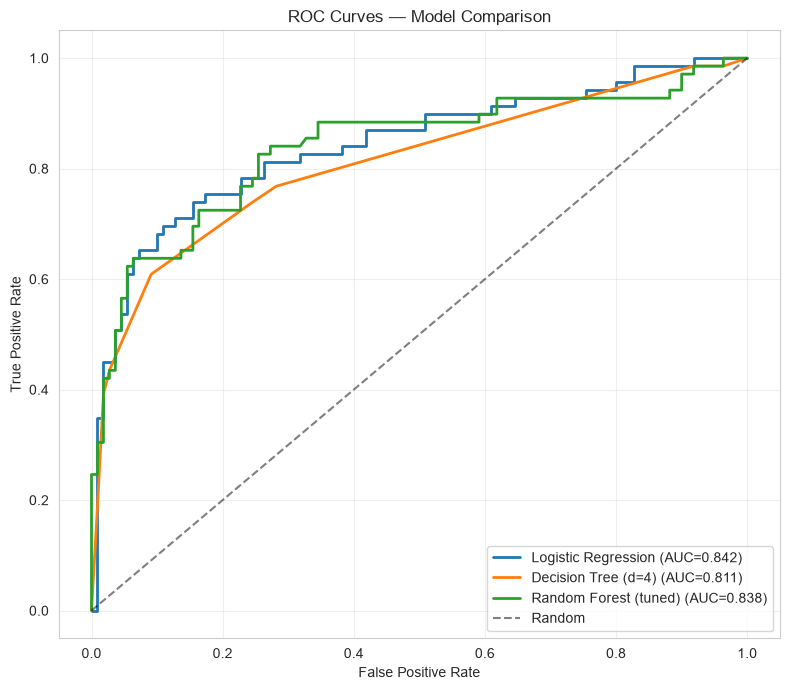

In [29]:
plt.figure(figsize=(8, 7))

for name, proba in [
    ("Logistic Regression", logreg_pipe.predict_proba(X_test)[:, 1]),
    ("Decision Tree (d=4)", tree_pipe.predict_proba(X_test)[:, 1]),
    ("Random Forest (tuned)", y_proba_best),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

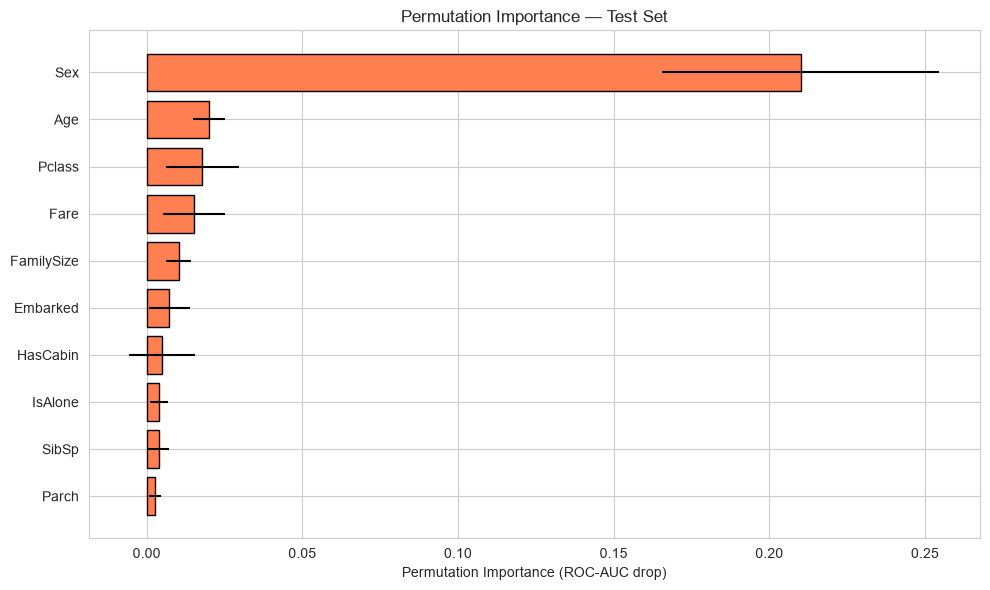

In [31]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
  best_rf , X_test , y_test ,
  n_repeats=10,
  random_state=42,
  n_jobs=-1,
  scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    perm_df["feature"],
    perm_df["importance_mean"],
    xerr=perm_df["importance_std"],
    # xerr → horizontal error bars (std across repeats)
    color="coral", edgecolor="black",
)
plt.xlabel("Permutation Importance (ROC-AUC drop)")
plt.title("Permutation Importance — Test Set")
plt.tight_layout()
plt.show()


In [32]:
cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring="roc_auc")


print(f"CV ROC-AUC scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV ROC-AUC scores: [0.8588 0.8237 0.8819 0.8733 0.9159]
Mean: 0.8707 ± 0.0301


## Summary

### Decision Tree
- **Interpretable** — you can draw it, read rules, explain to non-experts
- **Non-linear** — captures interactions automatically
- **Prone to overfitting** — must limit `max_depth` or `min_samples_leaf`
- **High variance** — small data changes → very different tree

### Random Forest
- **Ensemble of decorrelated trees** → variance drops
- **Minimal tuning needed** — works well out of the box
- **Feature importance** built-in (use `permutation_importance` for reliability)
- **Slow to predict** on huge data (many trees to traverse)

### When to Use Which

| Situation | Model |
|-----------|-------|
| Need explainable model | Decision Tree (shallow) |
| Best accuracy, no time to tune | Random Forest |
| Tabular data, mixed types | Random Forest |
| Need probability calibration | Logistic Regression |
| Very large data, need speed | XGBoost / LightGBM  |

## 🚀 Next

→ [03-knn-svm.ipynb](./03-knn-svm.ipynb): distance-based models. Completely different inductive bias.

In [33]:
import joblib
joblib.dump(best_rf, "rf_titanic.joblib")
print("Saved: rf_titanic.joblib")

Saved: rf_titanic.joblib
